## Module_3: Fibrosis

## Team Members:
Christina Johnson & Christian Grosso

## Fibrosis Image Analysis



## Project Goal:
The goal of this project is to analyze a large image sample of mouse lung tissue to determine the extent of fibrosis at different depths within the lung. By calculating the percentage of fibrotic (white) pixels in each image and using interpolation, the goal is to predict the amount of fibrosis at depths where data is not directly available.

## Disease Background: Idiopathic Pulmonary Fibrosis (IPF)
Prevalence & incidence
- IPF is a rare lung disease that mainly affects older adults, especially those over 60. Global incidence is about 5.8 cases per 100,000 people per year, and prevalence is about 17.7 per 100,000 people (Golchin et al., 2025).

Risk factors (genetic, lifestyle)
- Risk factors include genetic predisposition, environmental exposures (such as dust, smoke, smog, & pollution), and behaviors such as smoking

Diagnosis
- IPF is diagnosed using lung imaging (like CT scans), breathing tests, and sometimes a lung biopsy to confirm fibrosis in the lungs.

Symptoms
- Common symptoms are shortness of breath, a persistent dry cough, fatigue, and difficulty exercising. Additionally, IPF causes progressive difficulty breathing and reduced ability to perform daily activities due to declining lung function

Standard of care treatment(s)
- There is no cure, but treatments like antifibrotic drugs, oxygen therapy, and lung transplants can help manage symptoms and slow progression.

Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)
- IPF occurs when scar tissue builds up in the lungs. This thickens the lung tissue and makes it harder for oxygen to pass into the blood.

Clinical Trials / Next-Generation Therapies
- Research is currently being done on reducing tje fibrotic lung scarring. A new drug, nerandomilast, helps decrease inflammation and fibrosis in the lungs. Researchers are also doing targeted therapies, as well as stem cell and gene editing approaches, to repair damaged lung tissue and improve lung function.

## Data-Set: 
The dataset we used in this analysis includes 78 black-and-white images (.jpg images) of mouse lung tissue taken at different depths in the lung. In each image, white pixels show fibrotic (scarred) tissue and black pixels show healthy tissue. Each image also has a depth value, measured in micrometers.

To collect the data, researchers at the Peirce-Cottler Lab first caused lung fibrosis in mice using bleomycin. After a few weeks, the lungs were removed and sliced into thin sections using a microtome then placed on slides. The tissue was then stained and pictured under a microscope, and the images were converted into black-and-white so they could be analyzed more easily.

These images are used to calculate the percentage of fibrosis by comparing the number of white pixels to total pixels at each depth.

Data Source:
Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine.

## Data Analyis: 

To analyze the dataset, we processed each lung image to quantify the fibrosis. Each image was converted into a binary format, where white pixels represent fibrotic tissue and black pixels represent healthy tissue. We then counted pixels and calculated the percentage of white pixels for each image.

#### Step 1: Computing the pixel Counts and percent of fibrosis

- Each image (8 total of the 78 given) is converted to black-and-white
- White pixels (fibrosis) and black pixels (healthy tissue) are counted
- The percentage of fibrosis is calculated for each depth
- Results are saved to a .csv file for further analysis

In [5]:
# Code optimized with assistance from Claude (Anthropic, 2026) — claude.ai
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
import time 
start = time.time()

# Define filenames and corresponding depths
filenames = [
    r"images/MASK_SK658 Llobe ch010039.jpg",
    r"images/MASK_SK658 Llobe ch010030.jpg",
    r"images/MASK_SK658 Llobe ch010171.jpg",
    r"images/MASK_SK658 Slobe ch010147.jpg",
    r"images/MASK_SK658 Slobe ch010078.jpg",
    r"images/MASK_SK658 Slobe ch010142.jpg",
    r"images/MASK_SK658 Slobe ch010060.jpg",
    r"images/MASK_SK658 Slobe ch010098.jpg",
]

depths = [15, 200, 810, 3000, 4700, 7100, 8400, 10000]

# Load images and compute pixel counts in one pass
white_counts, black_counts, white_percents = [], [], []

for filename in filenames:
    binary = cv2.threshold(cv2.imread(filename, 0), 127, 255, cv2.THRESH_BINARY)[1]
    white = int(np.sum(binary == 255))
    black = int(np.sum(binary == 0))
    white_counts.append(white)
    black_counts.append(black)
    white_percents.append(100 * white / (white + black))

# Print pixel counts
print(colored("Counts of pixel by color in each image", "yellow"))
for x, (w, b) in enumerate(zip(white_counts, black_counts)):
    print(colored(f"White pixels in image {x}: {w}", "white"))
    print(colored(f"Black pixels in image {x}: {b}", "white"))
    print()

# Print percentages
print(colored("Percent white px:", "yellow"))
for filename, pct, depth in zip(filenames, white_percents, depths):
    print(colored(f'{filename}:', "red"))
    print(f'{pct:.2f}% White | Depth: {depth} microns\n')

# Write to CSV
df = pd.DataFrame({
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})
df.to_csv('Percent_White_Pixels.csv', index=False)

Counts of pixel by color in each image
White pixels in image 0: 21648
Black pixels in image 0: 4172656

White pixels in image 1: 37799
Black pixels in image 1: 4156505

White pixels in image 2: 57531
Black pixels in image 2: 4136773

White pixels in image 3: 80534
Black pixels in image 3: 4113770

White pixels in image 4: 92260
Black pixels in image 4: 4102044

White pixels in image 5: 116432
Black pixels in image 5: 4077872

White pixels in image 6: 142359
Black pixels in image 6: 4051945

White pixels in image 7: 383479
Black pixels in image 7: 3810825

Percent white px:
images/MASK_SK658 Llobe ch010039.jpg:
0.52% White | Depth: 15 microns

images/MASK_SK658 Llobe ch010030.jpg:
0.90% White | Depth: 200 microns

images/MASK_SK658 Llobe ch010171.jpg:
1.37% White | Depth: 810 microns

images/MASK_SK658 Slobe ch010147.jpg:
1.92% White | Depth: 3000 microns

images/MASK_SK658 Slobe ch010078.jpg:
2.20% White | Depth: 4700 microns

images/MASK_SK658 Slobe ch010142.jpg:
2.78% White | Depth: 

#### Step 2: Interpolation & Visualization (Linear & Quadratic Model)

##### 2a. Linear Estimation

- A user inputs a depth where no image data exists
- Linear interpolation is used to estimate the percent fibrosis at that depth
- The interpolated value is added to the existing dataset
- Two plots are generated: one with only measured data and one including the interpolated point
- The interpolated point is highlighted in red to show the predicted value

The interpolated point is at the x-coordinate 9000.0 and y-coordinate 5.549883842468262.


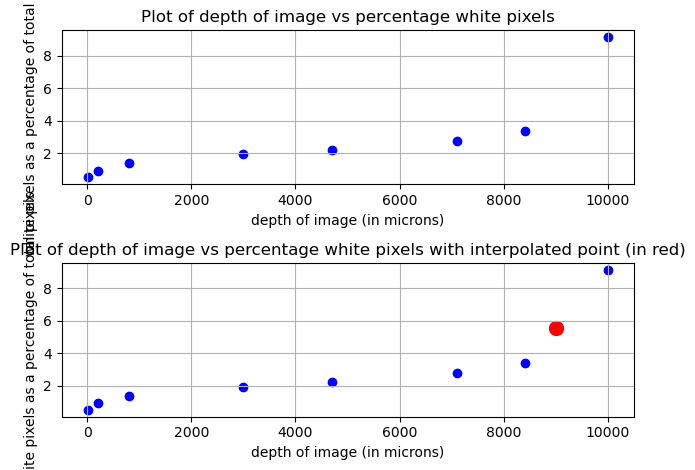

In [12]:
# Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored("Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

# Using a linear model to interpolate the point
i = interp1d(x, y, kind='linear')
interpolate_point = i(interpolate_depth)
print(colored(f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o', linestyle='-', color='blue')
axs[1].set_title('Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1], color='red', s=100, label='Highlighted point')


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


##### 2b. quadratic Estimation

- A user inputs a depth where no image data exists
- Quadratic interpolation is used to estimate the percent fibrosis at that depth
- The interpolated value is added to the existing dataset
- Two plots are generated: one with only measured data and one including the interpolated point
- The interpolated point is highlighted in red to show the predicted value

The interpolated point is at the x-coordinate 9000.0 and y-coordinate 4.818439929217517.


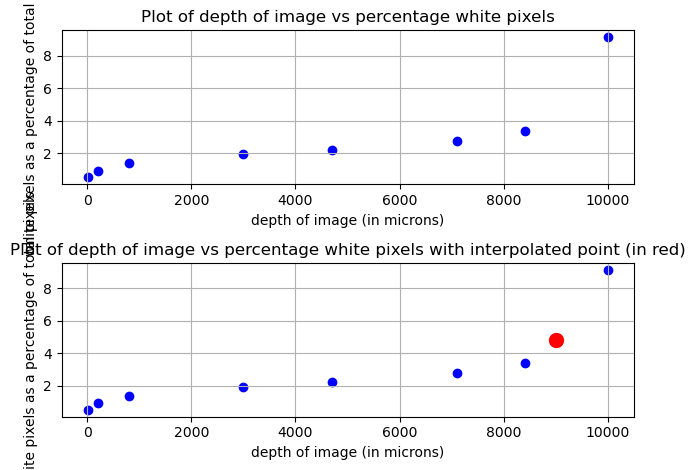

In [14]:
# Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored("Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

# Using a Quadratic model to interpolate the point
i = interp1d(x, y, kind='quadratic')
interpolate_point = i(interpolate_depth)
print(colored(f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o', linestyle='-', color='blue')
axs[1].set_title('Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1], color='red', s=100, label='Highlighted point')


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Verify and validate your analysis: 

To check how accurate our interpolation is, we chose a depth of 9000 µm, where we actually have an image but did not use it in our model.

We first calculate the real percent fibrosis from this image. Then, we compare it to the values predicted using linear and quadratic interpolation.

By comparing these values, we can calculate the error and determine which model is more accurate.

In [15]:
# Load the image at depth = 9000 microns
filename_9000 = r"images/MASK_SK658 Llobe ch010121.jpg"

# Convert to binary (black and white)
binary_9000 = cv2.threshold(cv2.imread(filename_9000, 0), 127, 255, cv2.THRESH_BINARY)[1]

# Count white and black pixels
white_9000 = int(np.sum(binary_9000 == 255))
black_9000 = int(np.sum(binary_9000 == 0))

# Compute percent white pixels
percent_white_9000 = 100 * white_9000 / (white_9000 + black_9000)

# Print results
print(colored("Actual data at depth = 9000 microns:", "yellow"))
print(f"White pixels: {white_9000}")
print(f"Black pixels: {black_9000}")
print(f"Percent white (fibrosis): {percent_white_9000:.2f}%")

Actual data at depth = 9000 microns:
White pixels: 161111
Black pixels: 4033193
Percent white (fibrosis): 3.84%


##### Error Analysis

The actual percent fibrosis at 9000 µm was 3.84%. We compared this to the interpolated values from both models.

- Linear interpolation prediction: 5.55%  
- Quadratic interpolation prediction: 4.82%  

We calculated percent error using:

Percent Error = |predicted − actual| / actual × 100

- Linear percent error:
= |5.55 − 3.84| / 3.84 × 100  
= 44.53%

- Quadratic percent error:
= |4.82 − 3.84| / 3.84 × 100  
= 25.52%

##### Conclusion from error analysis

The quadratic model has a lower percent error than the linear model, meaning it is more accurate for this dataset.  

This suggests that fibrosis does not change linearly with depth, and a quadratic model better represents the trend.

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:
Golchin, N., Patel, A., Scheuring, J., Wan, V., Hofer, K., Collet, J.-P., Elpers, B., & Lesperance, T. (2025). Incidence and prevalence of idiopathic pulmonary fibrosis: A systematic literature review and meta-analysis. BMC Pulmonary Medicine, 25, 378. https://doi.org/10.1186/s12890-025-03836-1

Sharif, R. (2017). Overview of idiopathic pulmonary fibrosis (IPF) and evidence-based guidelines. The American Journal of Managed Care, 23(11 Suppl), S176–S182.